# P1b RL Toy Example: Geometry

A minimal 2D geometry that preserves the P1b structure: one terrain hill, a fixed sensor, a terrain-tangent LOS boundary, a fixed powered-to-glide switching state, and a terminal goal.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Circle

FIGURE_DIR = Path.cwd() / "figure"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

Z_GRID = np.arange(0.0, 13.0, 1.0)
H_GRID = np.arange(0.0, 9.0, 1.0)
SWITCH_STATE = np.array([0.0, 8.0])
GOAL = np.array([12.0, 0.0])
GOAL_RADIUS = 0.45
SENSOR_Z = 10.0
CLEARANCE = 0.15
ACTIONS = np.array([(1, -1), (2, -1), (1, -2), (2, -2)], dtype=float)


In [2]:
def terrain_height(z):
    z = np.asarray(z, dtype=float)
    height = 2.8 * np.exp(-0.5 * ((z - 6.0) / 1.4) ** 2)
    return np.where(height < 0.01, 0.0, height)


def terrain_slope(z):
    z = np.asarray(z, dtype=float)
    return -(z - 6.0) / (1.4**2) * terrain_height(z)


SENSOR = np.array([SENSOR_Z, float(terrain_height(SENSOR_Z)) + 0.25])
candidate_z = np.linspace(6.0, SENSOR_Z - 1e-3, 20_000)
secant_slope = (SENSOR[1] - terrain_height(candidate_z)) / (SENSOR_Z - candidate_z)
tangent_index = int(np.argmin(np.abs(terrain_slope(candidate_z) - secant_slope)))
TANGENT_POINT = np.array([candidate_z[tangent_index], terrain_height(candidate_z[tangent_index])])
LOS_SLOPE = (SENSOR[1] - TANGENT_POINT[1]) / (SENSOR[0] - TANGENT_POINT[0])


def los_boundary(z):
    z = np.asarray(z, dtype=float)
    return SENSOR[1] + LOS_SLOPE * (z - SENSOR[0])


mesh_z, mesh_h = np.meshgrid(Z_GRID, H_GRID, indexing="ij")
terrain_valid = mesh_h >= terrain_height(mesh_z) + CLEARANCE
goal_mask = (mesh_z - GOAL[0]) ** 2 + (mesh_h - GOAL[1]) ** 2 <= GOAL_RADIUS**2
valid_state = terrain_valid | goal_mask
los_visible = (mesh_z >= SENSOR_Z) | (mesh_h >= np.maximum(terrain_height(mesh_z), los_boundary(mesh_z)))


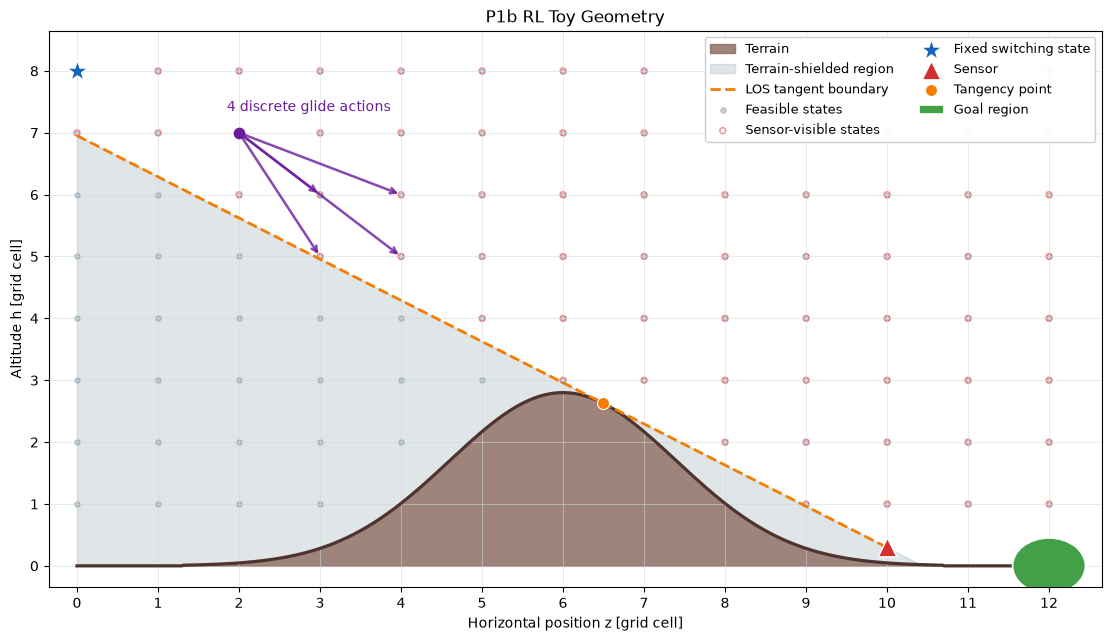

Saved: C:\Users\jeffe\Desktop\git\glider_hybrid_control\p1b_RL_toy_example\figure\001_p1b_RL_toy_geometry.png
Tangency point: z=6.496, h=2.630


In [3]:
z_fine = np.linspace(Z_GRID[0], Z_GRID[-1], 1000)
terrain_fine = terrain_height(z_fine)
boundary_fine = np.maximum(terrain_fine, los_boundary(z_fine))

fig, ax = plt.subplots(figsize=(11, 6.3), constrained_layout=True)
ax.fill_between(z_fine, 0.0, terrain_fine, color="#8d6e63", alpha=0.85, label="Terrain")
ax.fill_between(
    z_fine, terrain_fine, np.clip(boundary_fine, terrain_fine, H_GRID[-1]),
    where=boundary_fine > terrain_fine, color="#90a4ae", alpha=0.28,
    label="Terrain-shielded region",
)
ax.plot(z_fine, terrain_fine, color="#4e342e", linewidth=2.3)
left_of_sensor = z_fine <= SENSOR[0]
ax.plot(
    z_fine[left_of_sensor], los_boundary(z_fine[left_of_sensor]),
    color="#f57c00", linestyle="--", linewidth=2.0, label="LOS tangent boundary",
)

valid_points = np.column_stack((mesh_z[valid_state], mesh_h[valid_state]))
visible_points = np.column_stack((mesh_z[valid_state & los_visible], mesh_h[valid_state & los_visible]))
ax.scatter(valid_points[:, 0], valid_points[:, 1], s=14, color="#78909c", alpha=0.42, label="Feasible states")
ax.scatter(visible_points[:, 0], visible_points[:, 1], s=18, facecolors="none", edgecolors="#ef5350", alpha=0.65, label="Sensor-visible states")

ax.scatter(*SWITCH_STATE, marker="*", s=260, color="#1565c0", edgecolor="white", linewidth=1.0, zorder=8, label="Fixed switching state")
ax.scatter(*SENSOR, marker="^", s=180, color="#d32f2f", edgecolor="white", linewidth=1.0, zorder=8, label="Sensor")
ax.scatter(*TANGENT_POINT, marker="o", s=75, color="#f57c00", edgecolor="white", linewidth=0.8, zorder=8, label="Tangency point")
ax.add_patch(Circle(GOAL, GOAL_RADIUS, facecolor="#43a047", edgecolor="white", linewidth=1.2, zorder=8, label="Goal region"))

action_origin = np.array([2.0, 7.0])
for index, delta in enumerate(ACTIONS):
    ax.annotate(
        "", xy=action_origin + delta, xytext=action_origin,
        arrowprops={"arrowstyle": "->", "lw": 1.8, "color": "#6a1b9a", "alpha": 0.8},
    )
ax.scatter(*action_origin, s=55, color="#6a1b9a", zorder=8)
ax.text(action_origin[0] - 0.15, action_origin[1] + 0.35, "4 discrete glide actions", color="#6a1b9a", fontsize=10)

ax.set(
    xlim=(-0.35, 12.65), ylim=(-0.35, 8.65),
    xlabel="Horizontal position z [grid cell]", ylabel="Altitude h [grid cell]",
    title="P1b RL Toy Geometry",
)
ax.set_xticks(Z_GRID)
ax.set_yticks(H_GRID)
ax.grid(color="#cfd8dc", linewidth=0.7, alpha=0.55)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, loc="upper right", ncols=2, fontsize=9, framealpha=0.95)

output_path = FIGURE_DIR / "001_p1b_RL_toy_geometry.png"
fig.savefig(output_path, dpi=220, bbox_inches="tight")
plt.show()
print(f"Saved: {output_path}")
print(f"Tangency point: z={TANGENT_POINT[0]:.3f}, h={TANGENT_POINT[1]:.3f}")


## Discrete transition and action mask

Each action advances the glider and reduces altitude. An action is masked when its endpoint leaves the grid or any part of its segment enters terrain or the terrain-shielded region below the LOS boundary.

In [4]:
def state_to_index(state):
    return int(state[0] - Z_GRID[0]), int(state[1] - H_GRID[0])


def segment_is_feasible(state, next_state, sample_count=41):
    fraction = np.linspace(0.0, 1.0, sample_count)
    segment = state[None, :] + fraction[:, None] * (next_state - state)[None, :]
    terrain_clear = segment[:, 1] >= terrain_height(segment[:, 0]) - 1e-10
    visible = (segment[:, 0] >= SENSOR_Z) | (segment[:, 1] >= los_boundary(segment[:, 0]) - 1e-10)
    return bool(np.all(terrain_clear & visible))


def transition(state_index, action_index):
    zi, hi = state_index
    state = np.array([Z_GRID[zi], H_GRID[hi]], dtype=float)
    if goal_mask[zi, hi] or not (valid_state[zi, hi] and los_visible[zi, hi]):
        return None

    next_state = state + ACTIONS[action_index]
    inside = (
        Z_GRID[0] <= next_state[0] <= Z_GRID[-1]
        and H_GRID[0] <= next_state[1] <= H_GRID[-1]
    )
    if not inside or not segment_is_feasible(state, next_state):
        return None

    next_index = state_to_index(next_state)
    if not valid_state[next_index]:
        return None
    return {
        "state": state,
        "action_index": int(action_index),
        "next_state": next_state,
        "next_state_index": next_index,
        "done": bool(goal_mask[next_index]),
    }


action_mask = np.zeros((*valid_state.shape, len(ACTIONS)), dtype=bool)
next_state_index = np.full((*valid_state.shape, len(ACTIONS), 2), -1, dtype=int)
terminal_transition = np.zeros_like(action_mask)
for zi in range(len(Z_GRID)):
    for hi in range(len(H_GRID)):
        for ai in range(len(ACTIONS)):
            record = transition((zi, hi), ai)
            if record is None:
                continue
            action_mask[zi, hi, ai] = True
            next_state_index[zi, hi, ai] = record["next_state_index"]
            terminal_transition[zi, hi, ai] = record["done"]

# Backward reachability is diagnostic only; it is not used to hide valid actions.
goal_reachable = goal_mask.copy()
for zi in range(len(Z_GRID) - 1, -1, -1):
    for hi in range(len(H_GRID)):
        for ai in np.flatnonzero(action_mask[zi, hi]):
            nzi, nhi = next_state_index[zi, hi, ai]
            if goal_reachable[nzi, nhi]:
                goal_reachable[zi, hi] = True
                break

switch_index = state_to_index(SWITCH_STATE)
assert goal_reachable[switch_index], "The fixed switching state must reach the goal."
assert not np.any(action_mask[goal_mask]), "Goal states must have no outgoing action."
assert np.all(ACTIONS[:, 0] > 0), "Every transition must advance in z."
print(f"LOS-feasible glide states: {np.count_nonzero(valid_state & los_visible)}")
print(f"Physically feasible transitions: {np.count_nonzero(action_mask)}")
print(f"Goal-reachable states: {np.count_nonzero(goal_reachable)}")
print(f"Actions available at switching state: {np.flatnonzero(action_mask[switch_index]).tolist()}")


LOS-feasible glide states: 72
Physically feasible transitions: 204
Goal-reachable states: 51
Actions available at switching state: [0, 1, 3]


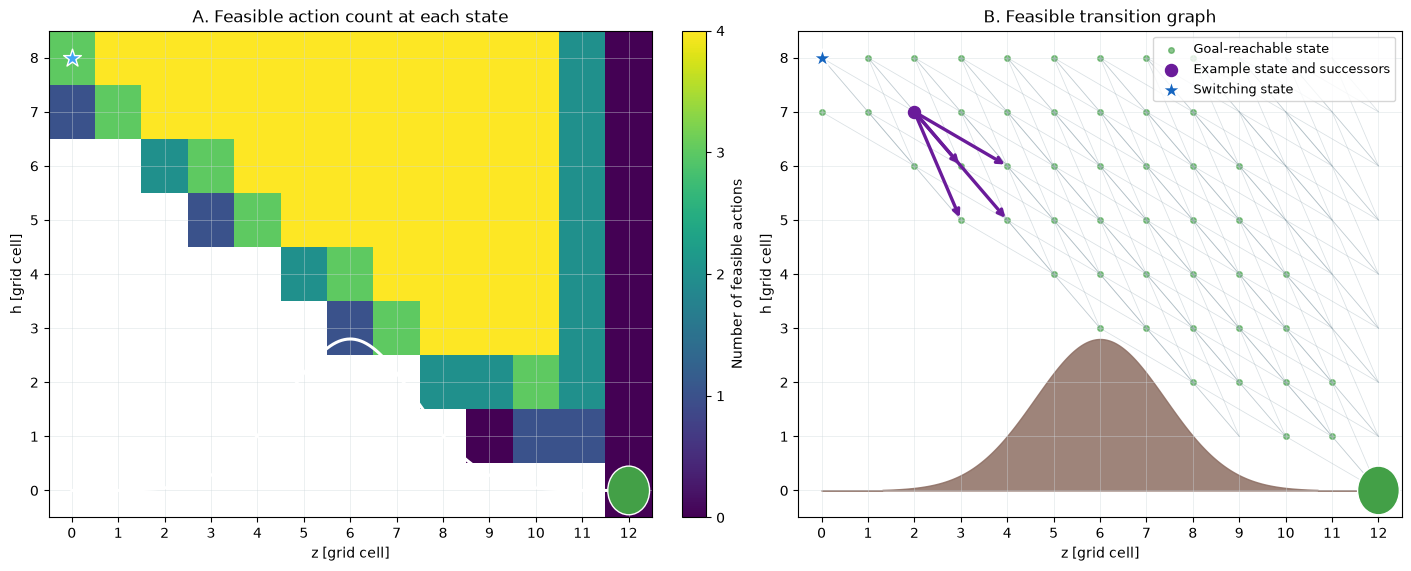

Saved: C:\Users\jeffe\Desktop\git\glider_hybrid_control\p1b_RL_toy_example\figure\002_p1b_RL_toy_transition_graph.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.6), constrained_layout=True)

action_count_map = np.sum(action_mask, axis=-1).astype(float)
action_count_map[~(valid_state & los_visible)] = np.nan
image = axes[0].imshow(
    action_count_map.T, origin="lower", extent=(-0.5, 12.5, -0.5, 8.5),
    vmin=0, vmax=len(ACTIONS), cmap="viridis", aspect="auto",
)
axes[0].plot(z_fine, terrain_fine, color="white", linewidth=2.2)
axes[0].scatter(*SWITCH_STATE, marker="*", s=180, color="#42a5f5", edgecolor="white", zorder=8)
axes[0].add_patch(Circle(GOAL, GOAL_RADIUS, facecolor="#43a047", edgecolor="white", zorder=8))
axes[0].set_title("A. Feasible action count at each state")
fig.colorbar(image, ax=axes[0], label="Number of feasible actions", ticks=range(len(ACTIONS) + 1))

axes[1].fill_between(z_fine, 0.0, terrain_fine, color="#8d6e63", alpha=0.85)
for zi in range(len(Z_GRID)):
    for hi in range(len(H_GRID)):
        state = np.array([Z_GRID[zi], H_GRID[hi]])
        for ai in np.flatnonzero(action_mask[zi, hi]):
            nzi, nhi = next_state_index[zi, hi, ai]
            successor = np.array([Z_GRID[nzi], H_GRID[nhi]])
            axes[1].plot(*np.column_stack((state, successor)), color="#90a4ae", linewidth=0.55, alpha=0.34)

reachable_points = np.column_stack((mesh_z[goal_reachable], mesh_h[goal_reachable]))
axes[1].scatter(reachable_points[:, 0], reachable_points[:, 1], s=16, color="#43a047", alpha=0.62, label="Goal-reachable state")
example_index = (2, 7)
example_state = np.array([Z_GRID[example_index[0]], H_GRID[example_index[1]]])
for ai in np.flatnonzero(action_mask[example_index]):
    nzi, nhi = next_state_index[*example_index, ai]
    successor = np.array([Z_GRID[nzi], H_GRID[nhi]])
    axes[1].annotate("", xy=successor, xytext=example_state, arrowprops={"arrowstyle": "->", "lw": 2.4, "color": "#6a1b9a"})
axes[1].scatter(*example_state, s=75, color="#6a1b9a", zorder=9, label="Example state and successors")
axes[1].scatter(*SWITCH_STATE, marker="*", s=180, color="#1565c0", edgecolor="white", zorder=8, label="Switching state")
axes[1].add_patch(Circle(GOAL, GOAL_RADIUS, facecolor="#43a047", edgecolor="white", zorder=8))
axes[1].set_title("B. Feasible transition graph")
axes[1].legend(loc="upper right", fontsize=9)

for ax in axes:
    ax.set(xlim=(-0.5, 12.5), ylim=(-0.5, 8.5), xlabel="z [grid cell]", ylabel="h [grid cell]")
    ax.set_xticks(Z_GRID)
    ax.set_yticks(H_GRID)
    ax.grid(color="#cfd8dc", linewidth=0.6, alpha=0.45)

output_path = FIGURE_DIR / "002_p1b_RL_toy_transition_graph.png"
fig.savefig(output_path, dpi=220, bbox_inches="tight")
plt.show()
print(f"Saved: {output_path}")


## Stage cost and RL reward

The Bellman solver minimizes detection hazard plus normalized flight time. RL receives the negative of exactly the same edge cost.

In [6]:
TOY_GLIDE_SPEED = 2.0
DETECTION_RANGE_SCALE = 3.0
HAZARD_REFERENCE = 1.0
REFERENCE_TIME = np.linalg.norm(GOAL - SWITCH_STATE) / TOY_GLIDE_SPEED
W_DETECTION = 0.5
W_TIME = 0.5


def detection_hazard_rate(points):
    points = np.asarray(points, dtype=float)
    sensor_range = np.linalg.norm(points - SENSOR, axis=-1)
    return np.exp(-sensor_range / DETECTION_RANGE_SCALE)


def edge_metrics(state_index, action_index, quadrature_count=41):
    record = transition(state_index, action_index)
    if record is None:
        return None
    state = record["state"]
    next_state = record["next_state"]
    duration = np.linalg.norm(next_state - state) / TOY_GLIDE_SPEED
    tau = np.linspace(0.0, 1.0, quadrature_count)
    points = state[None, :] + tau[:, None] * (next_state - state)[None, :]
    hazard = duration * np.trapezoid(detection_hazard_rate(points), tau)
    detection_cost = W_DETECTION * hazard / HAZARD_REFERENCE
    time_cost = W_TIME * duration / REFERENCE_TIME
    cost = detection_cost + time_cost
    return {
        **record,
        "duration": float(duration),
        "hazard": float(hazard),
        "detection_cost": float(detection_cost),
        "time_cost": float(time_cost),
        "cost": float(cost),
        "reward": float(-cost),
    }


edge_duration = np.full(action_mask.shape, np.nan)
edge_hazard = np.full(action_mask.shape, np.nan)
edge_cost = np.full(action_mask.shape, np.inf)
reward = np.full(action_mask.shape, -np.inf)
for zi in range(len(Z_GRID)):
    for hi in range(len(H_GRID)):
        for ai in np.flatnonzero(action_mask[zi, hi]):
            metrics = edge_metrics((zi, hi), ai)
            edge_duration[zi, hi, ai] = metrics["duration"]
            edge_hazard[zi, hi, ai] = metrics["hazard"]
            edge_cost[zi, hi, ai] = metrics["cost"]
            reward[zi, hi, ai] = metrics["reward"]

assert np.all(edge_cost[action_mask] > 0.0)
assert np.allclose(reward[action_mask], -edge_cost[action_mask])
print(f"Reference time: {REFERENCE_TIME:.3f}")
print(f"Edge cost range: {edge_cost[action_mask].min():.4f} to {edge_cost[action_mask].max():.4f}")
for ai in np.flatnonzero(action_mask[switch_index]):
    metrics = edge_metrics(switch_index, ai)
    print(f"switch action {ai}: detection={metrics['detection_cost']:.4f}, time={metrics['time_cost']:.4f}, cost={metrics['cost']:.4f}, reward={metrics['reward']:.4f}")


Reference time: 7.211
Edge cost range: 0.0557 to 0.5349
switch action 0: detection=0.0067, time=0.0490, cost=0.0557, reward=-0.0557
switch action 1: detection=0.0122, time=0.0775, cost=0.0898, reward=-0.0898
switch action 3: detection=0.0174, time=0.0981, cost=0.1155, reward=-0.1155


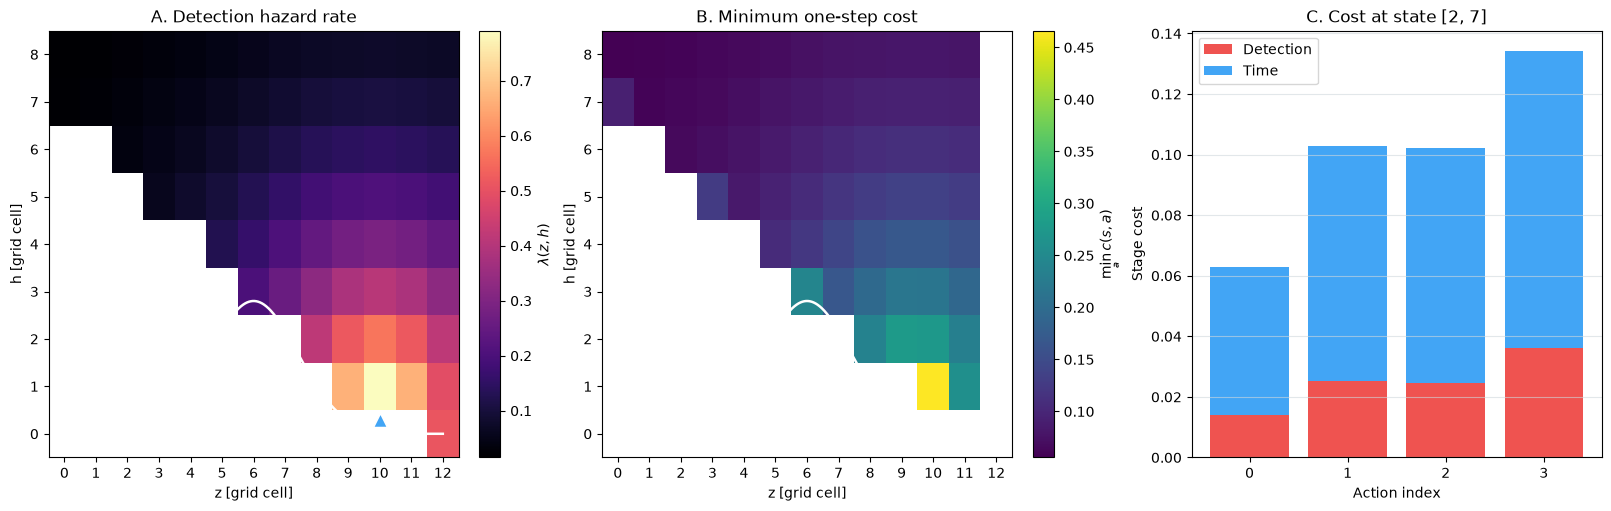

Saved: C:\Users\jeffe\Desktop\git\glider_hybrid_control\p1b_RL_toy_example\figure\003_p1b_RL_toy_stage_cost.png


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5.0), constrained_layout=True)

hazard_rate_map = detection_hazard_rate(np.stack((mesh_z, mesh_h), axis=-1))
hazard_rate_map[~(valid_state & los_visible)] = np.nan
hazard_image = axes[0].imshow(hazard_rate_map.T, origin="lower", extent=(-0.5, 12.5, -0.5, 8.5), cmap="magma", aspect="auto")
axes[0].scatter(*SENSOR, marker="^", s=100, color="#42a5f5", edgecolor="white", zorder=8)
axes[0].set_title("A. Detection hazard rate")
fig.colorbar(hazard_image, ax=axes[0], label=r"$\lambda(z,h)$")

minimum_edge_cost = np.min(edge_cost, axis=-1)
minimum_edge_cost[~np.isfinite(minimum_edge_cost)] = np.nan
cost_image = axes[1].imshow(minimum_edge_cost.T, origin="lower", extent=(-0.5, 12.5, -0.5, 8.5), cmap="viridis", aspect="auto")
axes[1].set_title("B. Minimum one-step cost")
fig.colorbar(cost_image, ax=axes[1], label=r"$\min_a c(s,a)$")

example_actions = np.flatnonzero(action_mask[example_index])
example_detection = np.array([edge_metrics(example_index, ai)["detection_cost"] for ai in example_actions])
example_time = np.array([edge_metrics(example_index, ai)["time_cost"] for ai in example_actions])
axes[2].bar(example_actions, example_detection, color="#ef5350", label="Detection")
axes[2].bar(example_actions, example_time, bottom=example_detection, color="#42a5f5", label="Time")
axes[2].set(xlabel="Action index", ylabel="Stage cost", title=f"C. Cost at state {example_state.astype(int).tolist()}")
axes[2].set_xticks(example_actions)
axes[2].legend()
axes[2].grid(axis="y", color="#cfd8dc", alpha=0.6)

for ax in axes[:2]:
    ax.plot(z_fine, terrain_fine, color="white", linewidth=1.8)
    ax.set(xlabel="z [grid cell]", ylabel="h [grid cell]")
    ax.set_xticks(Z_GRID)
    ax.set_yticks(H_GRID)

output_path = FIGURE_DIR / "003_p1b_RL_toy_stage_cost.png"
fig.savefig(output_path, dpi=220, bbox_inches="tight")
plt.show()
print(f"Saved: {output_path}")


## Exact Bellman reference

Because every action advances in $z$, the transition graph is acyclic. One backward sweep therefore gives the exact cost-to-go and greedy policy.

In [8]:
value = np.full(valid_state.shape, np.inf)
policy = np.full(valid_state.shape, -1, dtype=int)
value[goal_mask] = 0.0

for zi in range(len(Z_GRID) - 1, -1, -1):
    for hi in range(len(H_GRID)):
        if goal_mask[zi, hi]:
            continue
        q_cost = np.full(len(ACTIONS), np.inf)
        for ai in np.flatnonzero(action_mask[zi, hi]):
            nzi, nhi = next_state_index[zi, hi, ai]
            q_cost[ai] = edge_cost[zi, hi, ai] + value[nzi, nhi]
        best_action = int(np.argmin(q_cost))
        if np.isfinite(q_cost[best_action]):
            value[zi, hi] = q_cost[best_action]
            policy[zi, hi] = best_action

finite_value = np.isfinite(value)
assert np.array_equal(finite_value, goal_reachable)
residuals = []
for zi, hi in np.argwhere(policy >= 0):
    ai = policy[zi, hi]
    nzi, nhi = next_state_index[zi, hi, ai]
    residuals.append(abs(value[zi, hi] - edge_cost[zi, hi, ai] - value[nzi, nhi]))
maximum_bellman_residual = max(residuals, default=0.0)

trajectory = [SWITCH_STATE.copy()]
trajectory_actions = []
trajectory_edge_costs = []
trajectory_hazards = []
trajectory_durations = []
state_index = switch_index
for _ in range(valid_state.size):
    if goal_mask[state_index]:
        break
    ai = int(policy[state_index])
    if ai < 0:
        raise RuntimeError("Bellman policy reached a state without an action.")
    metrics = edge_metrics(state_index, ai)
    trajectory_actions.append(ai)
    trajectory_edge_costs.append(metrics["cost"])
    trajectory_hazards.append(metrics["hazard"])
    trajectory_durations.append(metrics["duration"])
    trajectory.append(metrics["next_state"])
    state_index = metrics["next_state_index"]

trajectory = np.asarray(trajectory)
mission_cost = float(np.sum(trajectory_edge_costs))
mission_reward = -mission_cost
mission_hazard = float(np.sum(trajectory_hazards))
mission_pod = 1.0 - np.exp(-mission_hazard)
mission_time = float(np.sum(trajectory_durations))
assert goal_mask[state_index]
assert np.isclose(mission_cost, value[switch_index])
assert maximum_bellman_residual < 1e-12
print(f"Bellman cost at switching state: {value[switch_index]:.6f}")
print(f"Equivalent optimal RL reward: {mission_reward:.6f}")
print(f"Mission PoD: {mission_pod:.6f}, time: {mission_time:.3f}, steps: {len(trajectory_actions)}")
print(f"Optimal actions: {trajectory_actions}")
print(f"Maximum Bellman residual: {maximum_bellman_residual:.1e}")


Bellman cost at switching state: 1.362251
Equivalent optimal RL reward: -1.362251
Mission PoD: 0.816618, time: 7.415, steps: 7
Optimal actions: [1, 1, 1, 1, 1, 0, 2]
Maximum Bellman residual: 1.1e-16


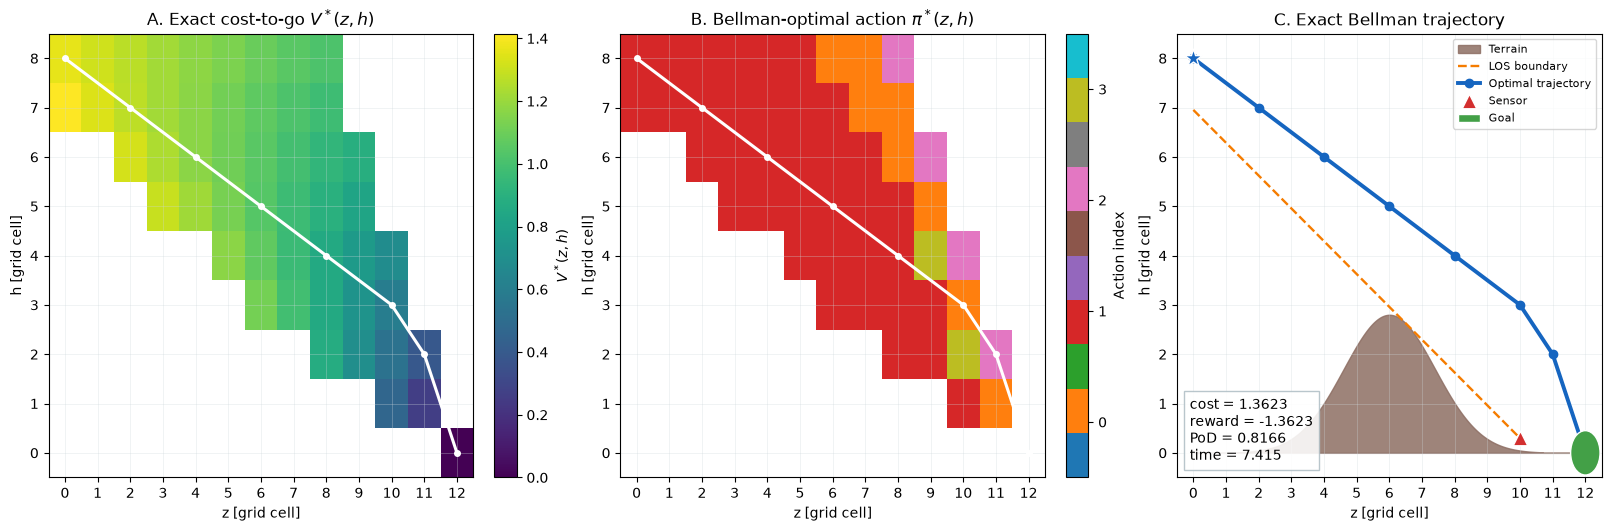

Saved: C:\Users\jeffe\Desktop\git\glider_hybrid_control\p1b_RL_toy_example\figure\004_p1b_RL_toy_bellman_solution.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5.2), constrained_layout=True)

value_plot = value.copy()
value_plot[~finite_value] = np.nan
value_image = axes[0].imshow(value_plot.T, origin="lower", extent=(-0.5, 12.5, -0.5, 8.5), cmap="viridis", aspect="auto")
axes[0].plot(trajectory[:, 0], trajectory[:, 1], color="white", marker="o", linewidth=2.2, markersize=4)
axes[0].set_title(r"A. Exact cost-to-go $V^*(z,h)$")
fig.colorbar(value_image, ax=axes[0], label=r"$V^*(z,h)$")

policy_plot = policy.astype(float)
policy_plot[policy < 0] = np.nan
policy_image = axes[1].imshow(policy_plot.T, origin="lower", extent=(-0.5, 12.5, -0.5, 8.5), cmap="tab10", vmin=-0.5, vmax=3.5, aspect="auto")
axes[1].plot(trajectory[:, 0], trajectory[:, 1], color="white", marker="o", linewidth=2.2, markersize=4)
axes[1].set_title(r"B. Bellman-optimal action $\pi^*(z,h)$")
fig.colorbar(policy_image, ax=axes[1], label="Action index", ticks=range(len(ACTIONS)))

axes[2].fill_between(z_fine, 0.0, terrain_fine, color="#8d6e63", alpha=0.85, label="Terrain")
axes[2].plot(z_fine[left_of_sensor], los_boundary(z_fine[left_of_sensor]), color="#f57c00", linestyle="--", linewidth=1.7, label="LOS boundary")
axes[2].plot(trajectory[:, 0], trajectory[:, 1], color="#1565c0", marker="o", linewidth=2.8, label="Optimal trajectory")
axes[2].scatter(*SENSOR, marker="^", s=110, color="#d32f2f", edgecolor="white", zorder=8, label="Sensor")
axes[2].scatter(*SWITCH_STATE, marker="*", s=180, color="#1565c0", edgecolor="white", zorder=8)
axes[2].add_patch(Circle(GOAL, GOAL_RADIUS, facecolor="#43a047", edgecolor="white", zorder=8, label="Goal"))
axes[2].text(0.03, 0.04, f"cost = {mission_cost:.4f}\nreward = {mission_reward:.4f}\nPoD = {mission_pod:.4f}\ntime = {mission_time:.3f}", transform=axes[2].transAxes, fontsize=10, bbox={"facecolor": "white", "alpha": 0.88, "edgecolor": "#b0bec5"})
axes[2].set_title("C. Exact Bellman trajectory")
axes[2].legend(loc="upper right", fontsize=8)

for ax in axes:
    ax.set(xlim=(-0.5, 12.5), ylim=(-0.5, 8.5), xlabel="z [grid cell]", ylabel="h [grid cell]")
    ax.set_xticks(Z_GRID)
    ax.set_yticks(H_GRID)
    ax.grid(color="#cfd8dc", linewidth=0.55, alpha=0.4)

output_path = FIGURE_DIR / "004_p1b_RL_toy_bellman_solution.png"
fig.savefig(output_path, dpi=220, bbox_inches="tight")
plt.show()
print(f"Saved: {output_path}")


## Tabular Q-learning

Q-learning does not use the Bellman value during training. The exact solution is used only afterward for quantitative evaluation. Episodes start from random goal-reachable states; final evaluation always starts from the fixed switching state.

In [10]:
RL_RANDOM_SEED = 20260817
LEARNING_EPISODES = 40_000
LEARNING_RATE = 0.20
EPSILON_START = 1.00
EPSILON_END = 0.02
HISTORY_INTERVAL = 200
SNAPSHOT_EPISODES = np.unique(np.rint(np.geomspace(1, LEARNING_EPISODES, 24)).astype(int))

# An RL action must be physically feasible and remain inside the terminal-reachable MDP.
learning_action_mask = np.zeros_like(action_mask)
reference_q_reward = np.full(action_mask.shape, np.nan)
for zi in range(len(Z_GRID)):
    for hi in range(len(H_GRID)):
        for ai in np.flatnonzero(action_mask[zi, hi]):
            nzi, nhi = next_state_index[zi, hi, ai]
            if finite_value[nzi, nhi]:
                learning_action_mask[zi, hi, ai] = True
                reference_q_reward[zi, hi, ai] = -(edge_cost[zi, hi, ai] + value[nzi, nhi])

training_states = np.argwhere(policy >= 0)
q_table = np.zeros(action_mask.shape, dtype=float)
rng = np.random.default_rng(RL_RANDOM_SEED)
history_episode = []
history_q_rmse = []
history_policy_agreement = []
history_switch_cost_gap = []
snapshot_episode = [0]
q_snapshots = [q_table.copy()]
snapshot_episode_set = set(SNAPSHOT_EPISODES.tolist())


def greedy_rollout(q_values):
    rollout_states = [SWITCH_STATE.copy()]
    rollout_actions = []
    rollout_cost = 0.0
    state_index = switch_index
    for _ in range(valid_state.size):
        if goal_mask[state_index]:
            return np.asarray(rollout_states), rollout_actions, float(rollout_cost)
        actions = np.flatnonzero(learning_action_mask[state_index])
        if actions.size == 0:
            raise RuntimeError("Q-learning rollout reached a state without an action.")
        ai = int(actions[np.argmax(q_values[state_index][actions])])
        nzi, nhi = next_state_index[*state_index, ai]
        rollout_cost += edge_cost[*state_index, ai]
        rollout_actions.append(ai)
        rollout_states.append(np.array([Z_GRID[nzi], H_GRID[nhi]]))
        state_index = (int(nzi), int(nhi))
    raise RuntimeError("Q-learning rollout exceeded the maximum step count.")


for episode in range(1, LEARNING_EPISODES + 1):
    epsilon = EPSILON_END + (EPSILON_START - EPSILON_END) * np.exp(-5.0 * episode / LEARNING_EPISODES)
    state_index = tuple(int(x) for x in training_states[rng.integers(len(training_states))])
    for _ in range(valid_state.size):
        actions = np.flatnonzero(learning_action_mask[state_index])
        if rng.random() < epsilon:
            ai = int(rng.choice(actions))
        else:
            ai = int(actions[np.argmax(q_table[state_index][actions])])
        nzi, nhi = next_state_index[*state_index, ai]
        next_index = (int(nzi), int(nhi))
        immediate_reward = reward[*state_index, ai]
        if goal_mask[next_index]:
            target = immediate_reward
        else:
            next_actions = np.flatnonzero(learning_action_mask[next_index])
            target = immediate_reward + np.max(q_table[next_index][next_actions])
        q_table[*state_index, ai] += LEARNING_RATE * (target - q_table[*state_index, ai])
        state_index = next_index
        if goal_mask[state_index]:
            break

    if episode in snapshot_episode_set:
        snapshot_episode.append(episode)
        q_snapshots.append(q_table.copy())

    if episode == 1 or episode % HISTORY_INTERVAL == 0:
        q_error = q_table[learning_action_mask] - reference_q_reward[learning_action_mask]
        agreements = []
        for zi, hi in training_states:
            actions = np.flatnonzero(learning_action_mask[zi, hi])
            learned_action = int(actions[np.argmax(q_table[zi, hi, actions])])
            agreements.append(learned_action == policy[zi, hi])
        _, _, switch_cost = greedy_rollout(q_table)
        history_episode.append(episode)
        history_q_rmse.append(float(np.sqrt(np.mean(q_error**2))))
        history_policy_agreement.append(float(np.mean(agreements)))
        history_switch_cost_gap.append(float(switch_cost - mission_cost))

learned_policy = np.full(policy.shape, -1, dtype=int)
learned_value = np.full(value.shape, np.inf)
learned_value[goal_mask] = 0.0
for zi, hi in training_states:
    actions = np.flatnonzero(learning_action_mask[zi, hi])
    learned_action = int(actions[np.argmax(q_table[zi, hi, actions])])
    learned_policy[zi, hi] = learned_action
    learned_value[zi, hi] = -np.max(q_table[zi, hi, actions])

learned_trajectory, learned_actions, learned_mission_cost = greedy_rollout(q_table)
final_q_rmse = float(np.sqrt(np.mean((q_table[learning_action_mask] - reference_q_reward[learning_action_mask]) ** 2)))
final_policy_agreement = float(np.mean(learned_policy[policy >= 0] == policy[policy >= 0]))
learned_reward = -learned_mission_cost
print(f"Final Q RMSE: {final_q_rmse:.6e}")
print(f"Policy agreement: {final_policy_agreement:.2%}")
print(f"Learned cost/reward: {learned_mission_cost:.6f} / {learned_reward:.6f}")
print(f"Bellman cost/reward: {mission_cost:.6f} / {mission_reward:.6f}")
print(f"Learned actions: {learned_actions}")
print(f"Trajectory matches Bellman: {np.array_equal(learned_trajectory, trajectory)}")


Final Q RMSE: 1.242817e-04
Policy agreement: 100.00%
Learned cost/reward: 1.362251 / -1.362251
Bellman cost/reward: 1.362251 / -1.362251
Learned actions: [1, 1, 1, 1, 1, 0, 2]
Trajectory matches Bellman: True


C:\Users\jeffe\AppData\Local\Temp\ipykernel_6884\110267056.py:10: RuntimeWarning: invalid value encountered in subtract
  value_error = np.abs(learned_value - value)


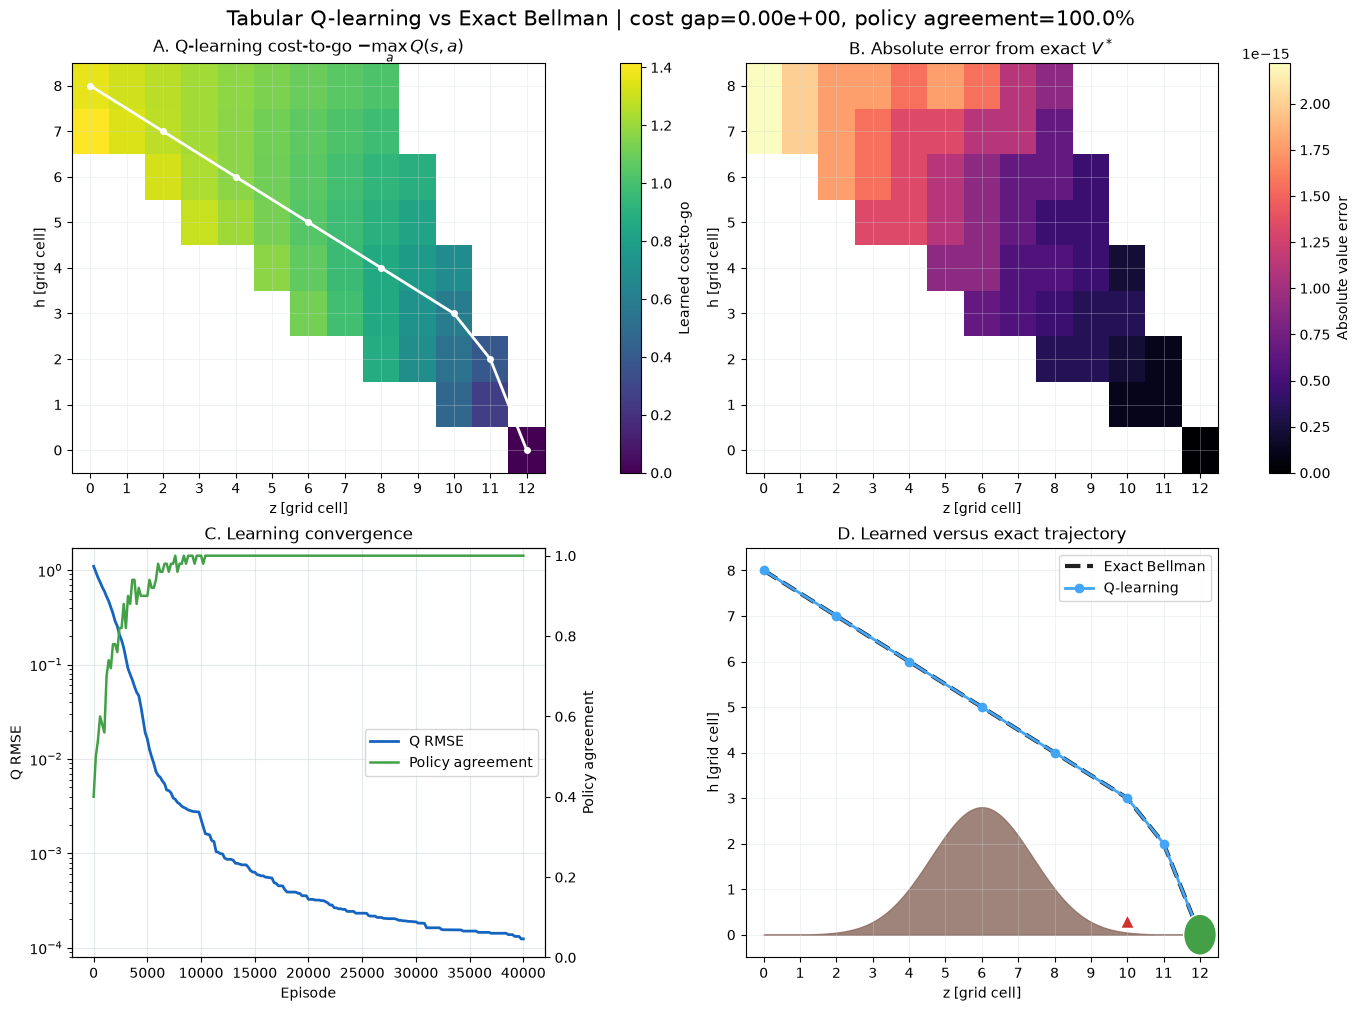

Saved: C:\Users\jeffe\Desktop\git\glider_hybrid_control\p1b_RL_toy_example\figure\005_p1b_RL_toy_q_learning.png


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(13.5, 10), constrained_layout=True)

learned_value_plot = learned_value.copy()
learned_value_plot[~finite_value] = np.nan
learned_image = axes[0, 0].imshow(learned_value_plot.T, origin="lower", extent=(-0.5, 12.5, -0.5, 8.5), cmap="viridis", aspect="auto")
axes[0, 0].plot(learned_trajectory[:, 0], learned_trajectory[:, 1], color="white", marker="o", linewidth=2.0, markersize=4)
axes[0, 0].set_title(r"A. Q-learning cost-to-go $-\max_a Q(s,a)$")
fig.colorbar(learned_image, ax=axes[0, 0], label="Learned cost-to-go")

value_error = np.abs(learned_value - value)
value_error[~finite_value] = np.nan
error_image = axes[0, 1].imshow(value_error.T, origin="lower", extent=(-0.5, 12.5, -0.5, 8.5), cmap="magma", aspect="auto")
axes[0, 1].set_title(r"B. Absolute error from exact $V^*$")
fig.colorbar(error_image, ax=axes[0, 1], label="Absolute value error")

axes[1, 0].plot(history_episode, history_q_rmse, color="#1565c0", linewidth=2.0, label="Q RMSE")
axes[1, 0].set(xlabel="Episode", ylabel="Q RMSE", title="C. Learning convergence")
axes[1, 0].set_yscale("log")
agreement_axis = axes[1, 0].twinx()
agreement_axis.plot(history_episode, history_policy_agreement, color="#43a047", linewidth=1.8, label="Policy agreement")
agreement_axis.set_ylabel("Policy agreement")
agreement_axis.set_ylim(0.0, 1.02)
lines = axes[1, 0].get_lines() + agreement_axis.get_lines()
axes[1, 0].legend(lines, [line.get_label() for line in lines], loc="center right")
axes[1, 0].grid(color="#cfd8dc", alpha=0.55)

axes[1, 1].fill_between(z_fine, 0.0, terrain_fine, color="#8d6e63", alpha=0.85)
axes[1, 1].plot(trajectory[:, 0], trajectory[:, 1], color="#212121", linestyle="--", linewidth=3.0, label="Exact Bellman")
axes[1, 1].plot(learned_trajectory[:, 0], learned_trajectory[:, 1], color="#42a5f5", marker="o", linewidth=2.0, label="Q-learning")
axes[1, 1].scatter(*SENSOR, marker="^", s=100, color="#d32f2f", edgecolor="white", zorder=8)
axes[1, 1].add_patch(Circle(GOAL, GOAL_RADIUS, facecolor="#43a047", edgecolor="white", zorder=8))
axes[1, 1].set_title("D. Learned versus exact trajectory")
axes[1, 1].legend(loc="upper right")

for ax in (axes[0, 0], axes[0, 1], axes[1, 1]):
    ax.set(xlim=(-0.5, 12.5), ylim=(-0.5, 8.5), xlabel="z [grid cell]", ylabel="h [grid cell]")
    ax.set_xticks(Z_GRID)
    ax.set_yticks(H_GRID)
    ax.grid(color="#cfd8dc", linewidth=0.55, alpha=0.4)

fig.suptitle(f"Tabular Q-learning vs Exact Bellman | cost gap={learned_mission_cost - mission_cost:.2e}, policy agreement={final_policy_agreement:.1%}", fontsize=15)
output_path = FIGURE_DIR / "005_p1b_RL_toy_q_learning.png"
fig.savefig(output_path, dpi=220, bbox_inches="tight")
plt.show()
print(f"Saved: {output_path}")


## Q-value propagation animation

Each frame shows the learned cost-to-go $\widehat V(s)=-\max_a Q(s,a)$ inside every goal-reachable cell. Checkpoints are logarithmically spaced so both early propagation and late convergence are visible.

In [12]:
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.patches import FancyArrowPatch

snapshot_values = []
snapshot_rmse = []
snapshot_agreement = []
for q_snapshot in q_snapshots:
    value_snapshot = np.full(value.shape, np.nan)
    value_snapshot[goal_mask] = 0.0
    agreements = []
    for zi, hi in training_states:
        actions = np.flatnonzero(learning_action_mask[zi, hi])
        value_snapshot[zi, hi] = -np.max(q_snapshot[zi, hi, actions])
        learned_action = int(actions[np.argmax(q_snapshot[zi, hi, actions])])
        agreements.append(learned_action == policy[zi, hi])
    snapshot_values.append(value_snapshot)
    q_error = q_snapshot[learning_action_mask] - reference_q_reward[learning_action_mask]
    snapshot_rmse.append(float(np.sqrt(np.mean(q_error**2))))
    snapshot_agreement.append(float(np.mean(agreements)))
snapshot_trajectories = [greedy_rollout(q_snapshot)[0] for q_snapshot in q_snapshots]

animation_cmap = plt.get_cmap("viridis").copy()
animation_cmap.set_bad("white")
fig, ax = plt.subplots(figsize=(4.0, 3.0), constrained_layout=True)
image = ax.imshow(
    snapshot_values[0].T, origin="lower", extent=(-0.5, 12.5, -0.5, 8.5),
    cmap=animation_cmap, vmin=0.0, vmax=float(np.max(value[finite_value])), aspect="auto",
)
colorbar = fig.colorbar(image, ax=ax, pad=0.02, label=r"Learned cost-to-go $\widehat V(s)$")
ax.set(xlabel="z [grid cell]", ylabel="h [grid cell]")
ax.set_xticks(Z_GRID)
ax.set_yticks(H_GRID)
ax.set_xticks(np.arange(-0.5, 13.0, 1.0), minor=True)
ax.set_yticks(np.arange(-0.5, 9.0, 1.0), minor=True)
ax.grid(which="minor", color="white", linewidth=0.45, alpha=0.7)
ax.tick_params(labelsize=6)
cell_text = {}
for zi, hi in np.argwhere(finite_value):
    cell_text[(zi, hi)] = ax.text(
        Z_GRID[zi], H_GRID[hi], "0.00", ha="center", va="center",
        fontsize=4.5, fontweight="bold", color="white", zorder=6,
    )
trajectory_line, = ax.plot([], [], color="#ff9800", marker="o", markersize=2.8, linewidth=1.8, zorder=4)
propagation_arrows = []
status_text = ax.text(
    0.01, 1.01, "", transform=ax.transAxes, ha="left", va="bottom", fontsize=6.2,
)
key_text = ax.text(
    0.01, 0.015, "cyan arrows: backward TD flow  |  orange-to-green: greedy trajectory",
    transform=ax.transAxes, ha="left", va="bottom", fontsize=4.2, zorder=8,
    bbox={"facecolor": "white", "alpha": 0.78, "edgecolor": "none"},
)


def update_value_frame(frame_index):
    frame_value = snapshot_values[frame_index]
    image.set_data(frame_value.T)
    for arrow in propagation_arrows:
        arrow.remove()
    propagation_arrows.clear()
    if frame_index > 0:
        value_change = np.abs(frame_value - snapshot_values[frame_index - 1])
        changed_states = [tuple(int(x) for x in state) for state in training_states if value_change[tuple(state)] > 1e-5]
        changed_states.sort(key=lambda state: value_change[state], reverse=True)
        for zi, hi in changed_states[:12]:
            actions = np.flatnonzero(learning_action_mask[zi, hi])
            ai = int(actions[np.argmax(q_snapshots[frame_index][zi, hi, actions])])
            nzi, nhi = next_state_index[zi, hi, ai]
            arrow = FancyArrowPatch(
                (Z_GRID[nzi], H_GRID[nhi]), (Z_GRID[zi], H_GRID[hi]),
                arrowstyle="-|>", mutation_scale=5.5, linewidth=0.75,
                color="#00e5ff", alpha=0.9, shrinkA=7, shrinkB=7, zorder=5,
            )
            ax.add_patch(arrow)
            propagation_arrows.append(arrow)
    current_trajectory = snapshot_trajectories[frame_index]
    agreement = snapshot_agreement[frame_index]
    early_color = np.array([1.00, 0.55, 0.00])
    converged_color = np.array([0.10, 0.70, 0.25])
    trajectory_line.set_data(current_trajectory[:, 0], current_trajectory[:, 1])
    trajectory_line.set_color((1.0 - agreement) * early_color + agreement * converged_color)
    maximum_value = float(np.max(value[finite_value]))
    for (zi, hi), label in cell_text.items():
        local_value = frame_value[zi, hi]
        display_value = 0.0 if abs(local_value) < 5e-4 else local_value
        label.set_text(f"{display_value:.2f}")
        label.set_color("black" if local_value / maximum_value > 0.62 else "white")
    status_text.set_text(
        f"Episode {snapshot_episode[frame_index]:,}   |   "
        f"Q RMSE {snapshot_rmse[frame_index]:.2e}   |   "
        f"policy {snapshot_agreement[frame_index]:.0%}"
    )
    ax.set_title("Q-learning value and policy propagation", fontsize=9, pad=13)
    return [image, trajectory_line, status_text, key_text, *propagation_arrows, *cell_text.values()]


value_animation = FuncAnimation(
    fig, update_value_frame, frames=len(snapshot_values), interval=400, blit=False, repeat=True,
)
output_path = FIGURE_DIR / "006_p1b_RL_toy_value_propagation.gif"
value_animation.save(output_path, writer=PillowWriter(fps=2.5), dpi=500)
plt.close(fig)
print(f"Saved: {output_path}")
print(f"Frames: {len(snapshot_values)}, FPS: 2.5, DPI: 500")


Saved: C:\Users\jeffe\Desktop\git\glider_hybrid_control\p1b_RL_toy_example\figure\006_p1b_RL_toy_value_propagation.gif
Frames: 25, FPS: 2.5, DPI: 500


## Convergence to the Bellman reference trajectory

The Bellman-optimal trajectory is now held fixed as an explicit reference. The Q-learning greedy trajectory is recomputed independently at every checkpoint so its convergence to the reference is directly visible.

In [13]:
import imageio_ffmpeg
from matplotlib.animation import FFMpegWriter
import matplotlib.patheffects as path_effects

plt.rcParams["animation.ffmpeg_path"] = imageio_ffmpeg.get_ffmpeg_exe()
snapshot_rollouts = [greedy_rollout(q_snapshot) for q_snapshot in q_snapshots]
snapshot_rollout_costs = [result[2] for result in snapshot_rollouts]
snapshot_path_matches = [np.array_equal(result[0], trajectory) for result in snapshot_rollouts]

video_cmap = plt.get_cmap("viridis").copy()
video_cmap.set_bad("white")
fig, ax = plt.subplots(figsize=(4.0, 3.0), constrained_layout=True)
video_image = ax.imshow(
    snapshot_values[0].T, origin="lower", extent=(-0.5, 12.5, -0.5, 8.5),
    cmap=video_cmap, vmin=0.0, vmax=float(np.max(value[finite_value])), aspect="auto",
)
fig.colorbar(video_image, ax=ax, pad=0.02, label=r"Learned cost-to-go $\widehat V(s)$")
reference_line, = ax.plot(
    trajectory[:, 0], trajectory[:, 1], color="#212121", linestyle="--",
    linewidth=1.5, marker="s", markersize=2.5, label="Bellman reference", zorder=4,
)
reference_line.set_path_effects([path_effects.Stroke(linewidth=3.0, foreground="white"), path_effects.Normal()])
video_trajectory_line, = ax.plot(
    [], [], color="#ff9800", linewidth=1.8, marker="o", markersize=2.8,
    label="Q-learning greedy", zorder=5,
)
video_cell_text = {}
for zi, hi in np.argwhere(finite_value):
    video_cell_text[(zi, hi)] = ax.text(
        Z_GRID[zi], H_GRID[hi], "0.00", ha="center", va="center",
        fontsize=4.5, fontweight="bold", color="white", zorder=7,
    )
video_status = ax.text(
    0.01, 1.008, "", transform=ax.transAxes, ha="left", va="bottom", fontsize=4.8, linespacing=1.15,
)
video_key = ax.text(
    0.01, 0.015, "cyan arrows: backward TD flow", transform=ax.transAxes,
    ha="left", va="bottom", fontsize=4.2, zorder=9,
    bbox={"facecolor": "white", "alpha": 0.78, "edgecolor": "none"},
)
video_arrows = []
ax.set(xlabel="z [grid cell]", ylabel="h [grid cell]")
ax.set_xticks(Z_GRID)
ax.set_yticks(H_GRID)
ax.set_xticks(np.arange(-0.5, 13.0, 1.0), minor=True)
ax.set_yticks(np.arange(-0.5, 9.0, 1.0), minor=True)
ax.grid(which="minor", color="white", linewidth=0.45, alpha=0.7)
ax.tick_params(labelsize=6)
ax.legend(loc="upper right", fontsize=4.7, framealpha=0.9)


def update_reference_frame(frame_index):
    frame_value = snapshot_values[frame_index]
    video_image.set_data(frame_value.T)
    for arrow in video_arrows:
        arrow.remove()
    video_arrows.clear()
    if frame_index > 0:
        value_change = np.abs(frame_value - snapshot_values[frame_index - 1])
        changed_states = [tuple(int(x) for x in state) for state in training_states if value_change[tuple(state)] > 1e-5]
        changed_states.sort(key=lambda state: value_change[state], reverse=True)
        for zi, hi in changed_states[:12]:
            actions = np.flatnonzero(learning_action_mask[zi, hi])
            ai = int(actions[np.argmax(q_snapshots[frame_index][zi, hi, actions])])
            nzi, nhi = next_state_index[zi, hi, ai]
            arrow = FancyArrowPatch(
                (Z_GRID[nzi], H_GRID[nhi]), (Z_GRID[zi], H_GRID[hi]),
                arrowstyle="-|>", mutation_scale=5.5, linewidth=0.75,
                color="#00e5ff", alpha=0.9, shrinkA=7, shrinkB=7, zorder=6,
            )
            ax.add_patch(arrow)
            video_arrows.append(arrow)
    current_trajectory = snapshot_rollouts[frame_index][0]
    agreement = snapshot_agreement[frame_index]
    early_color = np.array([1.00, 0.55, 0.00])
    converged_color = np.array([0.10, 0.70, 0.25])
    video_trajectory_line.set_data(current_trajectory[:, 0], current_trajectory[:, 1])
    video_trajectory_line.set_color((1.0 - agreement) * early_color + agreement * converged_color)
    maximum_value = float(np.max(value[finite_value]))
    for (zi, hi), label in video_cell_text.items():
        local_value = frame_value[zi, hi]
        display_value = 0.0 if abs(local_value) < 5e-4 else local_value
        label.set_text(f"{display_value:.2f}")
        label.set_color("black" if local_value / maximum_value > 0.62 else "white")
    cost_gap = snapshot_rollout_costs[frame_index] - mission_cost
    video_status.set_text(
        f"Episode {snapshot_episode[frame_index]:,} | policy {agreement:.0%} | "
        f"path match {snapshot_path_matches[frame_index]} | cost gap {cost_gap:.2e}"
    )
    ax.set_title("Q-learning convergence to Bellman reference", fontsize=8.5, pad=13)
    return [video_image, reference_line, video_trajectory_line, video_status, video_key, *video_arrows, *video_cell_text.values()]


reference_animation = FuncAnimation(
    fig, update_reference_frame, frames=len(snapshot_values), interval=400, blit=False, repeat=True,
)
output_path = FIGURE_DIR / "007_p1b_RL_toy_bellman_reference_convergence.mp4"
writer = FFMpegWriter(fps=2.5, codec="libx264", bitrate=5000, extra_args=["-pix_fmt", "yuv420p"])
reference_animation.save(output_path, writer=writer, dpi=500)
plt.close(fig)
print(f"Saved: {output_path}")
print(f"Frames: {len(snapshot_values)}, FPS: 2.5, DPI: 500")


Saved: C:\Users\jeffe\Desktop\git\glider_hybrid_control\p1b_RL_toy_example\figure\007_p1b_RL_toy_bellman_reference_convergence.mp4
Frames: 25, FPS: 2.5, DPI: 500


## Forward interaction versus backward TD backup

This video separates two directions that should not be conflated. Solid blue arrows show the agent's forward transitions along the current greedy rollout. Dashed cyan arrows point from successor to predecessor and show the TD target dependency for cells whose values changed most since the previous checkpoint. The dashed black path is the fixed Bellman reference. The backup arrows are a checkpoint-level diagnostic, not a claim that the agent physically travels backward.

In [14]:
from matplotlib.lines import Line2D

direction_cmap = plt.get_cmap("viridis").copy()
direction_cmap.set_bad("white")
fig, ax = plt.subplots(figsize=(4.0, 3.0), constrained_layout=False)
direction_image = ax.imshow(
    snapshot_values[0].T, origin="lower", extent=(-0.5, 12.5, -0.5, 8.5),
    cmap=direction_cmap, vmin=0.0, vmax=float(np.max(value[finite_value])), aspect="auto",
)
fig.colorbar(direction_image, ax=ax, pad=0.02, label=r"Learned cost-to-go $\widehat V(s)$")
fig.subplots_adjust(left=0.10, right=0.88, bottom=0.12, top=0.79)
direction_reference, = ax.plot(
    trajectory[:, 0], trajectory[:, 1], color="#212121", linestyle="--",
    linewidth=1.4, marker="s", markersize=2.3, zorder=4,
)
direction_reference.set_path_effects([path_effects.Stroke(linewidth=2.8, foreground="white"), path_effects.Normal()])
direction_cell_text = {}
for zi, hi in np.argwhere(finite_value):
    direction_cell_text[(zi, hi)] = ax.text(
        Z_GRID[zi], H_GRID[hi], "0.00", ha="center", va="center",
        fontsize=4.5, fontweight="bold", color="white", zorder=8,
    )
direction_status = ax.set_title("", fontsize=5.3, pad=5)
forward_arrows = []
backup_arrows = []
legend_handles = [
    Line2D([0], [0], color="#212121", linestyle="--", linewidth=1.5, label="Bellman reference"),
    Line2D([0], [0], color="#1976d2", linestyle="-", linewidth=2.0, label=r"Forward transition $s_t\to s_{t+1}$"),
    Line2D([0], [0], color="#00b8d4", linestyle="--", linewidth=1.5, label=r"TD backup $s_{t+1}\to Q(s_t,a_t)$"),
]
ax.legend(handles=legend_handles, loc="upper right", fontsize=4.3, framealpha=0.92)
ax.set(xlabel="z [grid cell]", ylabel="h [grid cell]")
ax.set_xticks(Z_GRID)
ax.set_yticks(H_GRID)
ax.set_xticks(np.arange(-0.5, 13.0, 1.0), minor=True)
ax.set_yticks(np.arange(-0.5, 9.0, 1.0), minor=True)
ax.grid(which="minor", color="white", linewidth=0.45, alpha=0.7)
ax.tick_params(labelsize=6)


def update_direction_frame(frame_index):
    frame_value = snapshot_values[frame_index]
    direction_image.set_data(frame_value.T)
    for artist in [*forward_arrows, *backup_arrows]:
        artist.remove()
    forward_arrows.clear()
    backup_arrows.clear()

    current_trajectory = snapshot_rollouts[frame_index][0]
    for start_point, end_point in zip(current_trajectory[:-1], current_trajectory[1:]):
        arrow = FancyArrowPatch(
            start_point, end_point, arrowstyle="-|>", mutation_scale=6.5,
            linewidth=1.45, linestyle="-", color="#1976d2", alpha=0.95,
            shrinkA=6, shrinkB=6, connectionstyle="arc3,rad=0.055", zorder=5,
        )
        ax.add_patch(arrow)
        forward_arrows.append(arrow)

    if frame_index > 0:
        value_change = np.abs(frame_value - snapshot_values[frame_index - 1])
        changed_states = [tuple(int(x) for x in state) for state in training_states if value_change[tuple(state)] > 1e-5]
        changed_states.sort(key=lambda state: value_change[state], reverse=True)
        for zi, hi in changed_states[:10]:
            actions = np.flatnonzero(learning_action_mask[zi, hi])
            ai = int(actions[np.argmax(q_snapshots[frame_index][zi, hi, actions])])
            nzi, nhi = next_state_index[zi, hi, ai]
            arrow = FancyArrowPatch(
                (Z_GRID[nzi], H_GRID[nhi]), (Z_GRID[zi], H_GRID[hi]),
                arrowstyle="-|>", mutation_scale=5.8, linewidth=0.9,
                linestyle=(0, (2, 2)), color="#00b8d4", alpha=0.95,
                shrinkA=7, shrinkB=7, connectionstyle="arc3,rad=-0.12", zorder=6,
            )
            ax.add_patch(arrow)
            backup_arrows.append(arrow)

    maximum_value = float(np.max(value[finite_value]))
    for (zi, hi), label in direction_cell_text.items():
        local_value = frame_value[zi, hi]
        display_value = 0.0 if abs(local_value) < 5e-4 else local_value
        label.set_text(f"{display_value:.2f}")
        label.set_color("black" if local_value / maximum_value > 0.62 else "white")

    cost_gap = snapshot_rollout_costs[frame_index] - mission_cost
    direction_status.set_text(
        "Forward interaction vs backward TD backup\n"
        f"Episode {snapshot_episode[frame_index]:,} | policy {snapshot_agreement[frame_index]:.0%}\n"
        f"path match {snapshot_path_matches[frame_index]} | cost gap {cost_gap:.2e}"
    )
    return [direction_image, direction_reference, direction_status, *forward_arrows, *backup_arrows, *direction_cell_text.values()]


direction_frame_sequence = np.repeat(np.arange(len(snapshot_values)), 4)
direction_animation = FuncAnimation(
    fig, update_direction_frame, frames=direction_frame_sequence, interval=400, blit=False, repeat=True,
)
output_path = FIGURE_DIR / "008_p1b_RL_toy_forward_vs_td_backup.mp4"
writer = FFMpegWriter(
    fps=2.5, codec="libx264", bitrate=5000,
    extra_args=["-pix_fmt", "yuv420p", "-g", "4", "-keyint_min", "4", "-sc_threshold", "0", "-movflags", "+faststart"],
)
direction_animation.save(output_path, writer=writer, dpi=500)
plt.close(fig)
print(f"Saved: {output_path}")
print(f"Frames: {len(direction_frame_sequence)}, FPS: 2.5, DPI: 500")


Saved: C:\Users\jeffe\Desktop\git\glider_hybrid_control\p1b_RL_toy_example\figure\008_p1b_RL_toy_forward_vs_td_backup.mp4
Frames: 100, FPS: 2.5, DPI: 500


## Geometry change: zero-shot reuse of the old Q-table

Change the sensor/LOS geometry, apply the already learned table without updating it, and compare against the new exact Bellman solution.

In [15]:
def build_geometry_variant(
    hill_center=6.0, hill_height=2.8, hill_width=1.4,
    sensor_z=10.0, sensor_height_offset=0.25,
):
    def terrain_variant(z):
        z = np.asarray(z, dtype=float)
        height = hill_height * np.exp(-0.5 * ((z - hill_center) / hill_width) ** 2)
        return np.where(height < 0.01, 0.0, height)

    def terrain_slope_variant(z):
        z = np.asarray(z, dtype=float)
        return -(z - hill_center) / hill_width**2 * terrain_variant(z)

    sensor = np.array([sensor_z, float(terrain_variant(sensor_z)) + sensor_height_offset])
    candidate_z = np.linspace(hill_center, sensor_z - 1e-3, 20_000)
    secant = (sensor[1] - terrain_variant(candidate_z)) / (sensor_z - candidate_z)
    tangent_index = int(np.argmin(np.abs(terrain_slope_variant(candidate_z) - secant)))
    tangent = np.array([candidate_z[tangent_index], terrain_variant(candidate_z[tangent_index])])
    los_slope = (sensor[1] - tangent[1]) / (sensor[0] - tangent[0])

    def los_variant(z):
        z = np.asarray(z, dtype=float)
        return sensor[1] + los_slope * (z - sensor[0])

    terrain_valid_variant = mesh_h >= terrain_variant(mesh_z) + CLEARANCE
    goal_mask_variant = (mesh_z - GOAL[0]) ** 2 + (mesh_h - GOAL[1]) ** 2 <= GOAL_RADIUS**2
    valid_variant = terrain_valid_variant | goal_mask_variant
    los_visible_variant = (mesh_z >= sensor_z) | (mesh_h >= np.maximum(terrain_variant(mesh_z), los_variant(mesh_z)))

    def segment_feasible_variant(state, next_state, sample_count=41):
        fraction = np.linspace(0.0, 1.0, sample_count)
        segment = state[None, :] + fraction[:, None] * (next_state - state)[None, :]
        terrain_clear = segment[:, 1] >= terrain_variant(segment[:, 0]) - 1e-10
        visible = (segment[:, 0] >= sensor_z) | (segment[:, 1] >= los_variant(segment[:, 0]) - 1e-10)
        return bool(np.all(terrain_clear & visible))

    action_mask_variant = np.zeros((*valid_variant.shape, len(ACTIONS)), dtype=bool)
    next_index_variant = np.full((*valid_variant.shape, len(ACTIONS), 2), -1, dtype=int)
    for zi in range(len(Z_GRID)):
        for hi in range(len(H_GRID)):
            if goal_mask_variant[zi, hi] or not (valid_variant[zi, hi] and los_visible_variant[zi, hi]):
                continue
            state = np.array([Z_GRID[zi], H_GRID[hi]])
            for ai, action in enumerate(ACTIONS):
                next_state = state + action
                inside = Z_GRID[0] <= next_state[0] <= Z_GRID[-1] and H_GRID[0] <= next_state[1] <= H_GRID[-1]
                if not inside or not segment_feasible_variant(state, next_state):
                    continue
                nzi, nhi = state_to_index(next_state)
                if valid_variant[nzi, nhi]:
                    action_mask_variant[zi, hi, ai] = True
                    next_index_variant[zi, hi, ai] = (nzi, nhi)

    reachable_variant = goal_mask_variant.copy()
    for zi in range(len(Z_GRID) - 1, -1, -1):
        for hi in range(len(H_GRID)):
            for ai in np.flatnonzero(action_mask_variant[zi, hi]):
                nzi, nhi = next_index_variant[zi, hi, ai]
                if reachable_variant[nzi, nhi]:
                    reachable_variant[zi, hi] = True
                    break

    learning_mask_variant = np.zeros_like(action_mask_variant)
    edge_cost_variant = np.full(action_mask_variant.shape, np.inf)
    for zi in range(len(Z_GRID)):
        for hi in range(len(H_GRID)):
            state = np.array([Z_GRID[zi], H_GRID[hi]])
            for ai in np.flatnonzero(action_mask_variant[zi, hi]):
                nzi, nhi = next_index_variant[zi, hi, ai]
                if not reachable_variant[nzi, nhi]:
                    continue
                learning_mask_variant[zi, hi, ai] = True
                next_state = np.array([Z_GRID[nzi], H_GRID[nhi]])
                duration = np.linalg.norm(next_state - state) / TOY_GLIDE_SPEED
                tau = np.linspace(0.0, 1.0, 41)
                points = state[None, :] + tau[:, None] * (next_state - state)[None, :]
                ranges = np.linalg.norm(points - sensor, axis=1)
                hazard = duration * np.trapezoid(np.exp(-ranges / DETECTION_RANGE_SCALE), tau)
                edge_cost_variant[zi, hi, ai] = W_DETECTION * hazard / HAZARD_REFERENCE + W_TIME * duration / REFERENCE_TIME

    value_variant = np.full(valid_variant.shape, np.inf)
    policy_variant = np.full(valid_variant.shape, -1, dtype=int)
    value_variant[goal_mask_variant] = 0.0
    for zi in range(len(Z_GRID) - 1, -1, -1):
        for hi in range(len(H_GRID)):
            if goal_mask_variant[zi, hi]:
                continue
            q_cost = np.full(len(ACTIONS), np.inf)
            for ai in np.flatnonzero(learning_mask_variant[zi, hi]):
                nzi, nhi = next_index_variant[zi, hi, ai]
                q_cost[ai] = edge_cost_variant[zi, hi, ai] + value_variant[nzi, nhi]
            ai = int(np.argmin(q_cost))
            if np.isfinite(q_cost[ai]):
                value_variant[zi, hi] = q_cost[ai]
                policy_variant[zi, hi] = ai

    def rollout_with_selector(selector):
        states = [SWITCH_STATE.copy()]
        actions_used = []
        total_cost = 0.0
        index = switch_index
        for _ in range(valid_variant.size):
            if goal_mask_variant[index]:
                return np.asarray(states), actions_used, total_cost, True
            actions = np.flatnonzero(learning_mask_variant[index])
            if actions.size == 0:
                break
            ai = int(selector(index, actions))
            nzi, nhi = next_index_variant[*index, ai]
            total_cost += edge_cost_variant[*index, ai]
            actions_used.append(ai)
            states.append(np.array([Z_GRID[nzi], H_GRID[nhi]]))
            index = (int(nzi), int(nhi))
        return np.asarray(states), actions_used, total_cost, False

    bellman_rollout = rollout_with_selector(lambda index, actions: policy_variant[index])
    return {
        "terrain": terrain_variant, "los": los_variant, "sensor": sensor, "tangent": tangent,
        "valid": valid_variant, "los_visible": los_visible_variant, "goal_mask": goal_mask_variant,
        "action_mask": action_mask_variant, "learning_mask": learning_mask_variant,
        "next_index": next_index_variant, "edge_cost": edge_cost_variant,
        "value": value_variant, "policy": policy_variant, "bellman_rollout": bellman_rollout,
        "rollout_with_selector": rollout_with_selector,
    }


changed_sensor_z = 11.0
changed_env = build_geometry_variant(sensor_z=changed_sensor_z, sensor_height_offset=0.25)
assert np.isfinite(changed_env["value"][switch_index]), "Laterally shifted geometry must remain solvable."
changed_bellman_trajectory, changed_bellman_actions, changed_bellman_cost, _ = changed_env["bellman_rollout"]
zero_shot_rollout = changed_env["rollout_with_selector"](
    lambda index, actions: actions[np.argmax(q_table[index][actions])]
)
zero_shot_trajectory, zero_shot_actions, zero_shot_cost, zero_shot_success = zero_shot_rollout
zero_shot_gap = zero_shot_cost - changed_bellman_cost if zero_shot_success else np.inf
zero_shot_unseen = sum(not learning_action_mask[*state_to_index(state), ai] for state, ai in zip(zero_shot_trajectory[:-1], zero_shot_actions))
print(f"Sensor moved laterally: z={SENSOR_Z:.1f} -> z={changed_sensor_z:.1f}")
print(f"Changed sensor follows terrain: {changed_env['sensor']}")
print(f"New Bellman actions/cost: {changed_bellman_actions} / {changed_bellman_cost:.6f}")
print(f"Old-Q zero-shot actions/cost: {zero_shot_actions} / {zero_shot_cost:.6f}")
print(f"Zero-shot success={zero_shot_success}, cost gap={zero_shot_gap:.6f}, unseen actions used={zero_shot_unseen}")


Sensor moved laterally: z=10.0 -> z=11.0
Changed sensor follows terrain: [11.    0.25]
New Bellman actions/cost: [1, 1, 1, 1, 1, 0, 2] / 1.380034
Old-Q zero-shot actions/cost: [2, 1, 0, 1, 1, 1, 1] / 1.459754
Zero-shot success=True, cost gap=0.079720, unseen actions used=4


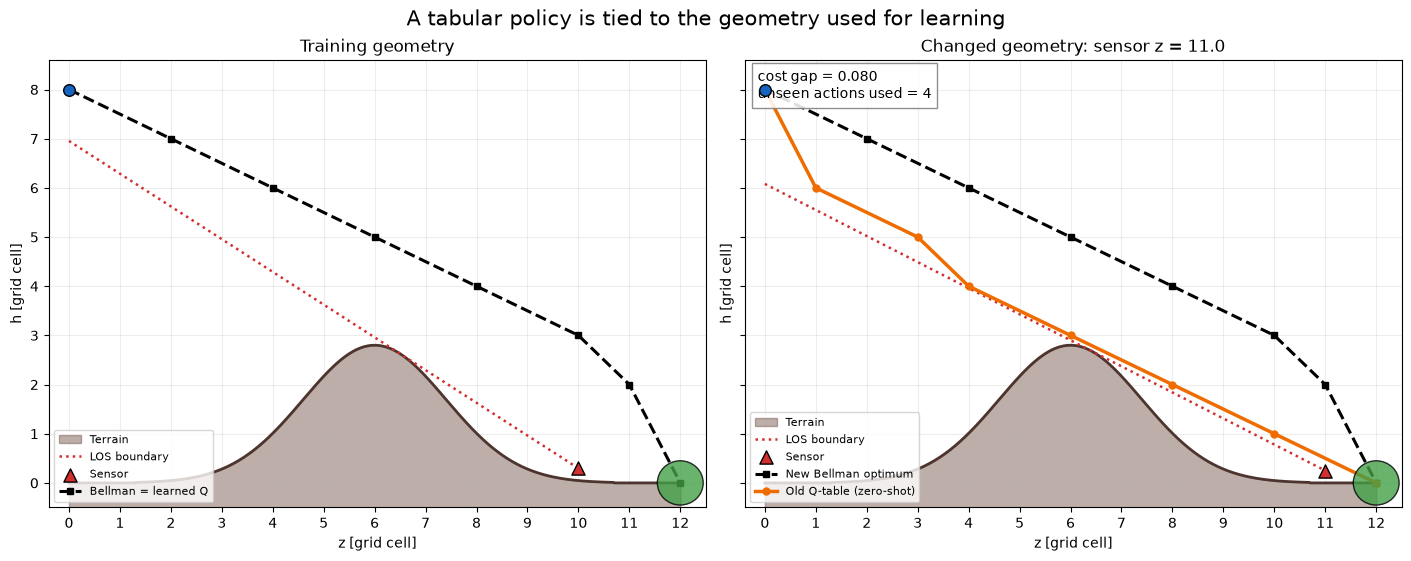

Saved: C:\Users\jeffe\Desktop\git\glider_hybrid_control\p1b_RL_toy_example\figure\009_p1b_RL_toy_geometry_change.png


In [16]:
def draw_variant_geometry(ax, terrain_function, los_function, sensor, title):
    z_plot = np.linspace(Z_GRID[0], Z_GRID[-1], 1000)
    terrain_plot = terrain_function(z_plot)
    ax.fill_between(z_plot, -0.6, terrain_plot, color="#6d4c41", alpha=0.45, label="Terrain")
    ax.plot(z_plot, terrain_plot, color="#4e342e", linewidth=2.0)
    los_z = z_plot[z_plot <= sensor[0]]
    ax.plot(los_z, los_function(los_z), color="#d32f2f", linestyle=":", linewidth=1.8, label="LOS boundary")
    ax.scatter(*sensor, marker="^", s=90, color="#d32f2f", edgecolor="black", zorder=6, label="Sensor")
    ax.add_patch(Circle(GOAL, GOAL_RADIUS, facecolor="#43a047", edgecolor="black", alpha=0.8, zorder=5))
    ax.scatter(*SWITCH_STATE, marker="o", s=70, color="#1565c0", edgecolor="black", zorder=6)
    ax.set(xlim=(-0.4, 12.5), ylim=(-0.5, 8.6), xlabel="z [grid cell]", ylabel="h [grid cell]", title=title)
    ax.set_xticks(Z_GRID)
    ax.set_yticks(H_GRID)
    ax.grid(alpha=0.22)


fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), constrained_layout=True, sharex=True, sharey=True)
draw_variant_geometry(axes[0], terrain_height, los_boundary, SENSOR, "Training geometry")
axes[0].plot(trajectory[:, 0], trajectory[:, 1], "k--s", linewidth=2.2, markersize=5, label="Bellman = learned Q")
axes[0].legend(loc="lower left", fontsize=8)

draw_variant_geometry(axes[1], changed_env["terrain"], changed_env["los"], changed_env["sensor"], f"Changed geometry: sensor z = {changed_sensor_z:.1f}")
axes[1].plot(changed_bellman_trajectory[:, 0], changed_bellman_trajectory[:, 1], "k--s", linewidth=2.2, markersize=5, label="New Bellman optimum")
axes[1].plot(zero_shot_trajectory[:, 0], zero_shot_trajectory[:, 1], color="#ef6c00", marker="o", linewidth=2.5, markersize=5, label="Old Q-table (zero-shot)")
if not zero_shot_success:
    axes[1].scatter(*zero_shot_trajectory[-1], marker="x", s=130, linewidth=3, color="#c62828", zorder=8, label="Failure")
gap_text = "failed" if not zero_shot_success else f"cost gap = {zero_shot_gap:.3f}"
axes[1].text(0.02, 0.98, f"{gap_text}\nunseen actions used = {zero_shot_unseen}", transform=axes[1].transAxes, va="top", fontsize=10, bbox=dict(facecolor="white", alpha=0.88, edgecolor="0.5"))
axes[1].legend(loc="lower left", fontsize=8)
fig.suptitle("A tabular policy is tied to the geometry used for learning", fontsize=15)
output_path = FIGURE_DIR / "009_p1b_RL_toy_geometry_change.png"
fig.savefig(output_path, dpi=500, bbox_inches="tight")
plt.show()
print(f"Saved: {output_path}")


## Changed geometry: scratch learning versus fine-tuning

Train on the laterally shifted sensor geometry either from a zero table or from the table learned on the original geometry.

In [17]:
ADAPT_EPISODES = 20_000
ADAPT_HISTORY_INTERVAL = 100
changed_learning_mask = changed_env["learning_mask"]
changed_training_states = np.argwhere(changed_env["policy"] >= 0)
changed_reference_q = np.full_like(q_table, np.nan)
for zi, hi in changed_training_states:
    for ai in np.flatnonzero(changed_learning_mask[zi, hi]):
        nzi, nhi = changed_env["next_index"][zi, hi, ai]
        changed_reference_q[zi, hi, ai] = -(
            changed_env["edge_cost"][zi, hi, ai] + changed_env["value"][nzi, nhi]
        )


def changed_q_metrics(q_values):
    q_error = q_values[changed_learning_mask] - changed_reference_q[changed_learning_mask]
    agreements = []
    for zi, hi in changed_training_states:
        actions = np.flatnonzero(changed_learning_mask[zi, hi])
        learned_action = int(actions[np.argmax(q_values[zi, hi, actions])])
        agreements.append(learned_action == changed_env["policy"][zi, hi])
    rollout = changed_env["rollout_with_selector"](
        lambda index, actions: actions[np.argmax(q_values[index][actions])]
    )
    cost_gap = rollout[2] - changed_bellman_cost if rollout[3] else np.inf
    return float(np.sqrt(np.mean(q_error**2))), float(np.mean(agreements)), float(cost_gap), rollout


def train_changed_geometry_q(initial_q, random_seed):
    q_values = np.zeros_like(q_table)
    q_values[changed_learning_mask] = initial_q[changed_learning_mask]
    local_rng = np.random.default_rng(random_seed)
    episodes = [0]
    rmse, agreement, gap, _ = changed_q_metrics(q_values)
    rmse_history = [rmse]
    agreement_history = [agreement]
    gap_history = [gap]

    for episode in range(1, ADAPT_EPISODES + 1):
        epsilon = EPSILON_END + (EPSILON_START - EPSILON_END) * np.exp(-5.0 * episode / ADAPT_EPISODES)
        index = tuple(int(x) for x in changed_training_states[local_rng.integers(len(changed_training_states))])
        for _ in range(changed_env["valid"].size):
            actions = np.flatnonzero(changed_learning_mask[index])
            if local_rng.random() < epsilon:
                ai = int(local_rng.choice(actions))
            else:
                ai = int(actions[np.argmax(q_values[index][actions])])
            nzi, nhi = changed_env["next_index"][*index, ai]
            next_index = (int(nzi), int(nhi))
            immediate_reward = -changed_env["edge_cost"][*index, ai]
            if changed_env["goal_mask"][next_index]:
                target = immediate_reward
            else:
                next_actions = np.flatnonzero(changed_learning_mask[next_index])
                target = immediate_reward + np.max(q_values[next_index][next_actions])
            q_values[*index, ai] += LEARNING_RATE * (target - q_values[*index, ai])
            index = next_index
            if changed_env["goal_mask"][index]:
                break

        if episode % ADAPT_HISTORY_INTERVAL == 0:
            rmse, agreement, gap, _ = changed_q_metrics(q_values)
            episodes.append(episode)
            rmse_history.append(rmse)
            agreement_history.append(agreement)
            gap_history.append(gap)

    final_metrics = changed_q_metrics(q_values)
    return {
        "q": q_values, "episode": np.asarray(episodes),
        "rmse": np.asarray(rmse_history), "agreement": np.asarray(agreement_history),
        "gap": np.asarray(gap_history), "final": final_metrics,
    }


scratch_initial_q = np.zeros_like(q_table)
fine_tune_initial_q = np.zeros_like(q_table)
shared_actions = changed_learning_mask & learning_action_mask
fine_tune_initial_q[shared_actions] = q_table[shared_actions]
scratch_adaptation = train_changed_geometry_q(scratch_initial_q, RL_RANDOM_SEED + 101)
fine_tune_adaptation = train_changed_geometry_q(fine_tune_initial_q, RL_RANDOM_SEED + 101)


def first_sustained_optimal_episode(result):
    optimal = np.isclose(result["agreement"], 1.0)
    for index in range(len(optimal)):
        if np.all(optimal[index:]):
            return int(result["episode"][index])
    return None


for label, result in [("Scratch", scratch_adaptation), ("Fine-tuning", fine_tune_adaptation)]:
    final_rmse, final_agreement, final_gap, final_rollout = result["final"]
    print(
        f"{label}: final RMSE={final_rmse:.3e}, policy={final_agreement:.1%}, "
        f"cost gap={final_gap:.3e}, sustained 100% episode={first_sustained_optimal_episode(result)}, "
        f"actions={final_rollout[1]}"
    )


Scratch: final RMSE=2.078e-03, policy=100.0%, cost gap=0.000e+00, sustained 100% episode=10400, actions=[1, 1, 1, 1, 1, 0, 2]
Fine-tuning: final RMSE=7.555e-04, policy=100.0%, cost gap=0.000e+00, sustained 100% episode=7800, actions=[1, 1, 1, 1, 1, 0, 2]


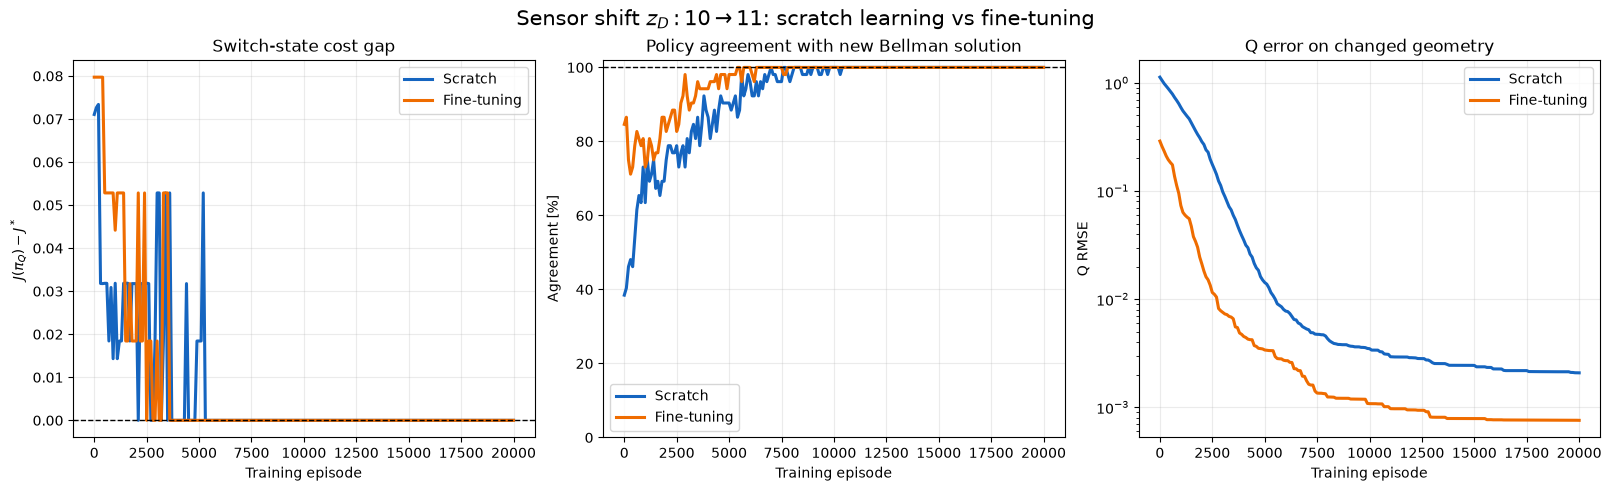

Saved: C:\Users\jeffe\Desktop\git\glider_hybrid_control\p1b_RL_toy_example\figure\010_p1b_RL_toy_scratch_vs_finetuning.png


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), constrained_layout=True)
adaptation_series = [
    ("Scratch", scratch_adaptation, "#1565c0"),
    ("Fine-tuning", fine_tune_adaptation, "#ef6c00"),
]
for label, result, color in adaptation_series:
    axes[0].plot(result["episode"], result["gap"], label=label, color=color, linewidth=2.2)
    axes[1].plot(result["episode"], 100.0 * result["agreement"], label=label, color=color, linewidth=2.2)
    axes[2].semilogy(result["episode"], result["rmse"], label=label, color=color, linewidth=2.2)
axes[0].axhline(0.0, color="black", linestyle="--", linewidth=1.0)
axes[1].axhline(100.0, color="black", linestyle="--", linewidth=1.0)
axes[0].set(title="Switch-state cost gap", xlabel="Training episode", ylabel=r"$J(\pi_Q)-J^*$")
axes[1].set(title="Policy agreement with new Bellman solution", xlabel="Training episode", ylabel="Agreement [%]", ylim=(0, 102))
axes[2].set(title="Q error on changed geometry", xlabel="Training episode", ylabel="Q RMSE")
for ax in axes:
    ax.grid(alpha=0.25)
    ax.legend()
fig.suptitle(r"Sensor shift $z_D:10\rightarrow11$: scratch learning vs fine-tuning", fontsize=15)
output_path = FIGURE_DIR / "010_p1b_RL_toy_scratch_vs_finetuning.png"
fig.savefig(output_path, dpi=500, bbox_inches="tight")
plt.show()
print(f"Saved: {output_path}")


## Equation Ledger

This cell is the living mathematical specification for the toy problem. It will be updated whenever the model changes.

### Implemented

**State**

$$s=(z,h), \qquad z\in\{0,\ldots,12\},\quad h\in\{0,\ldots,8\}.$$

**Discrete glide actions**

$$\mathcal A=\{(1,-1),(2,-1),(1,-2),(2,-2)\}.$$

**Deterministic transition**

$$s' = f(s,a)=s+a.$$

**Terrain**

$$T(z)=2.8\exp\!\left[-\frac{1}{2}\left(\frac{z-6}{1.4}\right)^2\right],$$
with numerical tails below $0.01$ truncated to zero.

**LOS tangent boundary**

For sensor position $s_D=(z_D,h_D)$ and tangency point $(z_t,T(z_t))$,

$$L(z)=h_D+\frac{h_D-T(z_t)}{z_D-z_t}(z-z_D),$$

where the tangency condition is

$$T'(z_t)=\frac{h_D-T(z_t)}{z_D-z_t}.$$

**Feasible glide segment**

For every point $(z(\tau),h(\tau))$ on an edge, $\tau\in[0,1]$,

$$h(\tau)\ge T(z(\tau)),$$

and

$$z(\tau)\ge z_D \quad\text{or}\quad h(\tau)\ge L(z(\tau)).$$

**Detection hazard and edge duration**

$$\rho(x)=\lVert x-s_D\rVert_2, \qquad \lambda(x)=\exp\!\left(-\frac{\rho(x)}{R_0}\right), \qquad R_0=3.$$

$$\Delta t(s,a)=\frac{\lVert a\rVert_2}{v_g}, \qquad v_g=2,$$

$$H(s,a)=\Delta t(s,a)\int_0^1 \lambda(s+\tau a)\,d\tau.$$

**Stage cost and RL reward**

$$c(s,a)=w_{\mathrm{det}}\frac{H(s,a)}{H_{\mathrm{ref}}}+w_{\mathrm{time}}\frac{\Delta t(s,a)}{T_{\mathrm{ref}}}, \qquad r(s,a)=-c(s,a),$$

with $w_{\mathrm{det}}=w_{\mathrm{time}}=0.5$, $H_{\mathrm{ref}}=1$, and $T_{\mathrm{ref}}=\lVert s_{\mathrm{goal}}-s_{\mathrm{switch}}\rVert_2/v_g$.

**Exact Bellman reference**

$$Q_c^*(s,a)=c(s,a)+V^*(f(s,a)),$$

$$V^*(s)=\min_{a\in\mathcal A(s)}Q_c^*(s,a), \qquad \pi^*(s)=\arg\min_{a\in\mathcal A(s)}Q_c^*(s,a), \qquad V^*(s_{\mathrm{goal}})=0.$$

For the same trajectory, the optimal RL return is $R^*(s)=-V^*(s)$.

**Tabular Q-learning**

The environment interaction is forward, while the TD target carries successor information back to the sampled predecessor:

$$s_t\xrightarrow{a_t} (r_t,s_{t+1}), \qquad Q(s_{t+1},\cdot)\xrightarrow{\text{TD backup}}Q(s_t,a_t).$$

With $\gamma=1$ for this finite acyclic episode,

$$Q(s,a)\leftarrow Q(s,a)+\eta\left[r(s,a)+\max_{a'\in\mathcal A(s')}Q(s',a')-Q(s,a)\right],$$

and the learned greedy policy and cost-to-go are

$$\pi_Q(s)=\arg\max_{a\in\mathcal A(s)}Q(s,a), \qquad \widehat V(s)=-\max_{a\in\mathcal A(s)}Q(s,a).$$

**Geometry-change zero-shot test**

After changing geometry parameters from $\theta_0$ to $\theta_1$, the old table is evaluated without any update:

$$\pi_{Q,0}(s)=\arg\max_{a\in\mathcal A_{\theta_1}(s)}Q_{\theta_0}(s,a), \qquad \Delta J=J_{\theta_1}(\pi_{Q,0})-J_{\theta_1}(\pi^*_{\theta_1}).$$

This measures reuse of the old table; it is not retraining or transfer learning.

**Scratch versus fine-tuning after a geometry change**

Both agents use the new transition and reward model. Their only difference is initialization:

$$Q^{\mathrm{scratch}}_0(s,a)=0, \qquad Q^{\mathrm{fine}}_0(s,a)=Q^*_{\theta_0}(s,a) \;\text{for shared feasible actions}.$$

Both are then updated using samples from the changed geometry $\theta_1$.

### Next to implement

Add sensor position to the state, train across multiple geometries, then introduce **Tabular Soft Q-learning** followed by discrete SAC.